# 7CS070/UZ2: Concepts & Technologies of Artificial Intelligence

## Assessment Task 2 - Classification

- **Module:** 7CS070/UZ2: Concepts & Technologies of Artificial Intelligence
- **Author:** Santiago Cruz | **ID:** 2584023
- **Dataset:** NYSE: Oracle (`ORCL`), Daily Bars, 1986-2026 (TradingView export)
- **Task:** Predict next-day price direction (Up/Down) using two classification algorithms (K-Nearest Neighbors, Support Vector Machine), compare performance, and discuss improvements.

Full explanation, references, and discussion are in the accompanying written report - this notebook holds the working code.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print('Libraries loaded.')

## 1. Load and Clean the Data

In [2]:
# Load the ORCL daily OHLC + indicator export
orcl_1d_data = pd.read_csv('NYSE_BATS_ORCL_1D.csv')
orcl_1d_data['time'] = pd.to_datetime(orcl_1d_data['time'], errors='coerce')
orcl_1d_data = orcl_1d_data.dropna(subset=['time']).drop_duplicates().sort_values('time').set_index('time')

numeric_cols = ['open', 'high', 'low', 'close', 'SMA_756_Close', 'SMA_504_Close', 'SMA_252_Close',
                 'SMA_125_Close', 'SMA_63_Close', 'SMA_21_Close', 'TSI_25_13_13', 'TSI_Signal_13',
                 'RSI_25_Close', 'RSI_SMA_14']
for col in numeric_cols:
    orcl_1d_data[col] = pd.to_numeric(orcl_1d_data[col], errors='coerce')

print('Shape:', orcl_1d_data.shape)
orcl_1d_data.tail()

Shape: (10185, 18)


,open,high,low,close,SMA_756_Close,SMA_VWMA_756,SMA_504_Close,SMA_VWMA_504,SMA_252_Close,SMA_125_Close,SMA_63_Close,SMA_21_Close,TSI_25_13_13,TSI_Signal_13,RSI_25_Close,RSI_SMA_14,New_Moon,Full_Moon
time,,,,,,,,,,,,,,,,,,
2026-08-17,148.450,150.40,145.50,146.65,163.106349,162.796656,185.401309,185.173918,196.041071,161.88480,162.534921,135.714286,5.976252,-8.324582,48.864477,47.214831,0,0
2026-08-18,143.250,146.00,142.35,142.79,163.145675,162.825287,185.418234,185.189188,195.622460,161.77776,161.839365,136.733810,5.052806,-6.413526,47.291485,48.064536,0,0
2026-08-19,142.695,146.08,137.43,143.81,163.183029,162.869739,185.434524,185.215177,195.204762,161.67592,161.241746,137.531905,4.545954,-4.847886,47.754424,48.588301,0,0
2026-08-20,144.300,145.92,141.02,142.07,163.215807,162.904020,185.444722,185.236814,194.837500,161.62784,160.510159,138.304762,3.688181,-3.628448,47.020571,48.980040,0,0
2026-08-21,143.715,148.35,142.60,146.47,163.256984,162.955902,185.462579,185.271016,194.485952,161.66912,159.822857,139.563333,4.042427,-2.532609,49.081685,49.135719,0,0


### 1.1 Price History (Context)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(orcl_1d_data.index, orcl_1d_data['close'], color='black', linewidth=0.8)
ax.set_title('ORCL Close Price, 1986-2026')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
plt.tight_layout()
plt.show()

orcl_1d_data[['open', 'high', 'low', 'close']].describe().round(3)

## 2. Feature Engineering

Same technical-indicator features as Task 1. Target: **next-day direction** - a binary label
(1 = price closes higher tomorrow, 0 = price closes lower or unchanged).

In [3]:
df = orcl_1d_data.copy()

df['return_1d'] = df['close'].pct_change()
df['volatility_10d'] = df['return_1d'].rolling(10).std()
df['dist_sma21'] = (df['close'] - df['SMA_21_Close']) / df['SMA_21_Close']
df['dist_sma63'] = (df['close'] - df['SMA_63_Close']) / df['SMA_63_Close']
df['dist_sma252'] = (df['close'] - df['SMA_252_Close']) / df['SMA_252_Close']
df['rsi'] = df['RSI_25_Close']
df['tsi'] = df['TSI_25_13_13']
df['tsi_signal'] = df['TSI_Signal_13']

# Target: did price close higher the next day? (binary classification)
df['next_return'] = df['close'].shift(-1) / df['close'] - 1
df['target_direction'] = (df['next_return'] > 0).astype(int)

feature_cols = ['return_1d', 'volatility_10d', 'dist_sma21', 'dist_sma63', 'dist_sma252', 'rsi', 'tsi', 'tsi_signal']
df = df.dropna(subset=feature_cols + ['target_direction']).copy()

print('Feature matrix shape:', df[feature_cols].shape)
print('\nClass balance:')
print(df['target_direction'].value_counts(normalize=True).round(3))

Feature matrix shape: (9934, 8)

Class balance:
target_direction
0    0.502
1    0.498
Name: proportion, dtype: float64


### 2.1 Class Balance and Feature Distributions

In [ ]:
class_pct = df['target_direction'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Down (0)', 'Up (1)'], class_pct.values, color=['#e74c3c', '#2ecc71'])
for bar, pct in zip(bars, class_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{pct:.1f}%', ha='center')
ax.set_title('Class Balance: Next-Day Direction')
ax.set_ylabel('Percentage of Days (%)')
ax.set_ylim(0, max(class_pct.values) + 10)
plt.tight_layout()
plt.show()

print('Feature descriptive statistics:')
print(df[feature_cols].describe().round(4))

## 3. Quick Visual Check: Which Features Actually Relate to the Target?

Same idea as Task 1: check, before modelling, which features look related to next-day direction
and which look close to noise. Since the target here is binary (0/1), a Pearson correlation
against it is equivalent to a point-biserial correlation - a standard way to screen features
against a binary outcome.

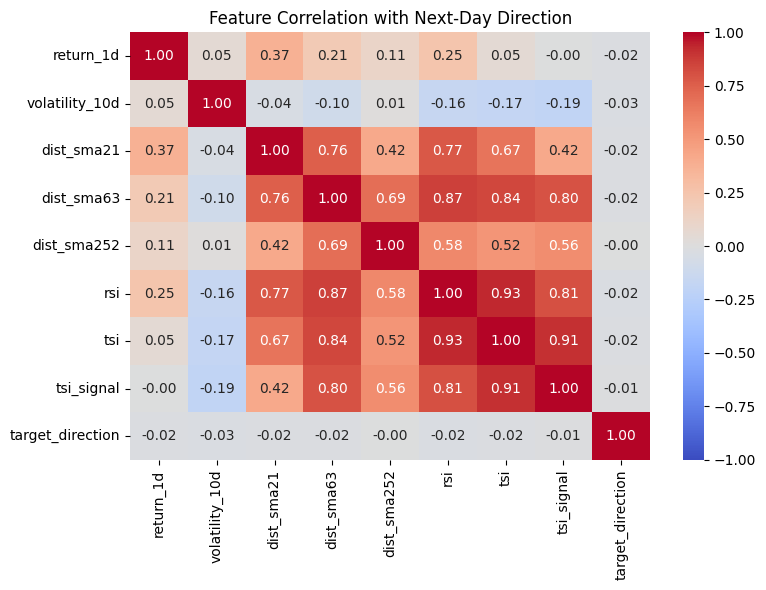

Correlation of each feature with the target, sorted by strength:
volatility_10d   -0.028855
rsi              -0.023591
dist_sma21       -0.021538
dist_sma63       -0.017986
tsi              -0.016725
return_1d        -0.016587
tsi_signal       -0.010405
dist_sma252      -0.000077
Name: target_direction, dtype: float64


In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[feature_cols + ['target_direction']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation with Next-Day Direction')
plt.tight_layout()
plt.show()

print('Correlation of each feature with the target, sorted by strength:')
print(corr['target_direction'].drop('target_direction').sort_values(key=abs, ascending=False))

In [ ]:
top3_features = corr['target_direction'].drop('target_direction').abs().sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, feat in zip(axes, top3_features):
    sns.boxplot(data=df, x='target_direction', y=feat, ax=ax, hue='target_direction',
                palette={0: '#e74c3c', 1: '#2ecc71'}, legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Down', 'Up'])
    ax.set_title(feat)
    ax.set_xlabel('')
plt.suptitle('Top 3 Correlated Features, Split by Next-Day Direction')
plt.tight_layout()
plt.show()

print('If a feature separated the two classes well, its Up/Down boxes above would sit at clearly different levels -')
print('here they overlap almost completely, consistent with the near-zero correlations found above.')

## 4. Train/Test Split and Feature Scaling

A chronological split, as in Task 1 (never random, for the same look-ahead-leakage reason). KNN
and SVM are both **distance-based** algorithms, so features must be scaled to comparable ranges
first - otherwise a feature like `dist_sma252` (values around +/-0.3) would dominate a feature
like `rsi` (values 0-100) purely because of its numeric scale, not because it is more
informative.

In [5]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df['target_direction']
X_test, y_test = test_df[feature_cols], test_df['target_direction']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {train_df.index.min().date()} to {train_df.index.max().date()} ({len(train_df)} rows)')
print(f'Test:  {test_df.index.min().date()} to {test_df.index.max().date()} ({len(test_df)} rows)')

Train: 1987-03-10 to 2018-09-24 (7947 rows)
Test:  2018-09-25 to 2026-08-21 (1987 rows)


## 5. Baseline

Always predicts the majority class - any real classifier must beat this.

In [6]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)
print('Baseline accuracy:', round(accuracy_score(y_test, baseline_pred), 4))

Baseline accuracy: 0.4751


## 6. Algorithm 1: K-Nearest Neighbors (KNN)

Classifies a new day by majority vote among its `k` most similar historical days (by feature
distance) - there is no explicit training step; all the work happens at prediction time.

In [7]:
knn_model = KNeighborsClassifier(n_neighbors=15)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, knn_pred)
knn_bal_acc = balanced_accuracy_score(y_test, knn_pred)
print(f'KNN -> Accuracy: {knn_acc:.4f} | Balanced Accuracy: {knn_bal_acc:.4f}')
print(classification_report(y_test, knn_pred, target_names=['Down', 'Up']))

KNN -> Accuracy: 0.4947 | Balanced Accuracy: 0.4959
              precision    recall  f1-score   support

        Down       0.47      0.52      0.49       944
          Up       0.52      0.47      0.50      1043

    accuracy                           0.49      1987
   macro avg       0.50      0.50      0.49      1987
weighted avg       0.50      0.49      0.49      1987



In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

knn_proba = knn_model.predict_proba(X_test_scaled)[:, 1]
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_proba)
knn_auc = roc_auc_score(y_test, knn_proba)
print(f'KNN ROC-AUC: {knn_auc:.4f}')

## 7. Algorithm 2: Support Vector Machine (SVM)

Finds the boundary that best separates the two classes; the RBF kernel used here allows that
boundary to be curved rather than a straight line.

In [ ]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, svm_pred)
svm_bal_acc = balanced_accuracy_score(y_test, svm_pred)
print(f'SVM -> Accuracy: {svm_acc:.4f} | Balanced Accuracy: {svm_bal_acc:.4f}')
print(classification_report(y_test, svm_pred, target_names=['Down', 'Up']))

In [ ]:
svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_proba)
svm_auc = roc_auc_score(y_test, svm_proba)
print(f'SVM ROC-AUC: {svm_auc:.4f}')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(knn_fpr, knn_tpr, label=f'KNN (AUC = {knn_auc:.3f})', color='#3498db')
ax.plot(svm_fpr, svm_tpr, label=f'SVM (AUC = {svm_auc:.3f})', color='#2ecc71')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance (AUC = 0.500)')
ax.set_title('ROC Curve: KNN vs. SVM')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Model Comparison

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Baseline (Majority)', 'KNN', 'SVM'],
    'Accuracy': [accuracy_score(y_test, baseline_pred), knn_acc, svm_acc],
    'Balanced Accuracy': [balanced_accuracy_score(y_test, baseline_pred), knn_bal_acc, svm_bal_acc],
    'F1 (macro)': [f1_score(y_test, baseline_pred, average='macro'),
                    f1_score(y_test, knn_pred, average='macro'),
                    f1_score(y_test, svm_pred, average='macro')],
    'ROC-AUC': [np.nan, knn_auc, svm_auc],
}).round(4)
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width / 2, comparison['Accuracy'], width, label='Accuracy', color='#3498db')
ax.bar(x + width / 2, comparison['Balanced Accuracy'], width, label='Balanced Accuracy', color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance level')
ax.set_ylabel('Score')
ax.set_title('Classifier Comparison - Accuracy vs. Balanced Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
ConfusionMatrixDisplay(confusion_matrix(y_test, knn_pred), display_labels=['Down', 'Up']).plot(ax=axes[0, 0], cmap='Blues', colorbar=False)
axes[0, 0].set_title('KNN - Counts')
ConfusionMatrixDisplay(confusion_matrix(y_test, knn_pred, normalize='true'), display_labels=['Down', 'Up']).plot(ax=axes[0, 1], cmap='Blues', colorbar=False, values_format='.1%')
axes[0, 1].set_title('KNN - Row Percentage')
ConfusionMatrixDisplay(confusion_matrix(y_test, svm_pred), display_labels=['Down', 'Up']).plot(ax=axes[1, 0], cmap='Greens', colorbar=False)
axes[1, 0].set_title('SVM - Counts')
ConfusionMatrixDisplay(confusion_matrix(y_test, svm_pred, normalize='true'), display_labels=['Down', 'Up']).plot(ax=axes[1, 1], cmap='Greens', colorbar=False, values_format='.1%')
axes[1, 1].set_title('SVM - Row Percentage')
plt.tight_layout()
plt.show()

## Summary

See the accompanying written report for the full discussion: how each algorithm works (with
references), why one outperformed the other on this dataset, and suggested improvements
(feature selection, alternative features, tuning `k` / the SVM kernel, etc.).